In [135]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [136]:
gal_south = np.load("galaxy_south_reduced.npz")
gal_north = np.load("galaxy_north_reduced.npz")
rand_south = np.load("random_south_reduced.npz")
rand_north = np.load("random_north_reduced.npz")

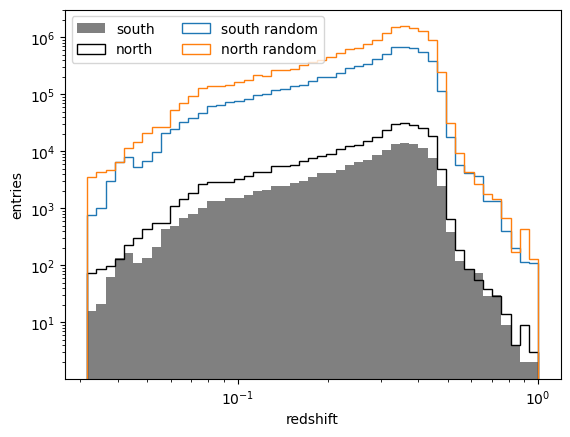

In [137]:
z_bins = np.logspace(-1.5, 0, 50)
plt.hist(gal_south["z"], bins=z_bins, color='gray', label='south')
plt.hist(gal_north["z"], bins=z_bins, histtype='step', color='black', label='north')
plt.hist(rand_south["z"], bins=z_bins, histtype='step', label='south random')
plt.hist(rand_north["z"], bins=z_bins, histtype='step', label='north random')

plt.xscale('log')
plt.xlabel('redshift')

plt.yscale('log')
plt.ylabel('entries')

plt.legend(loc=2, ncol=2)

plt.show()

In [138]:
gal_plane_l = np.linspace(0, 360, 100)
gal_plane = SkyCoord(l=gal_plane_l, b=0, frame='galactic', unit='deg').icrs
sorted = np.argsort(gal_plane.ra.deg)

In [139]:
gal_north1 = np.array([gal_north["ra"], gal_north["dec"], gal_north["z"]])
gal_south1 = np.array([gal_south["ra"], gal_south["dec"], gal_south["z"]])
gal = np.hstack((gal_north1, gal_south1)).T
galaxies = pd.DataFrame(gal, columns=["ra", "dec", "z"])

In [140]:
rand_north1 = np.array([rand_north["ra"], rand_north["dec"], rand_north["z"]])
rand_south1 = np.array([rand_south["ra"], rand_south["dec"], rand_south["z"]])
rand = np.hstack((rand_north1, rand_south1)).T
randoms = pd.DataFrame(rand, columns=["ra", "dec", "z"])

In [141]:
galaxies_cut = galaxies[(galaxies["z"] <= 0.05) * (galaxies["z"] > 0.01)]
randoms_cut = randoms[(randoms["z"] <= 0.05) * (randoms["z"] > 0.01)]

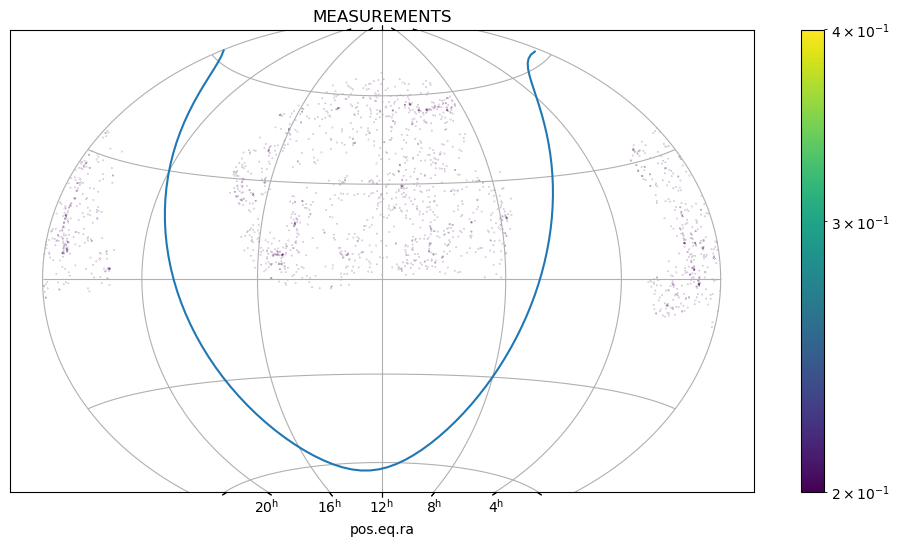

In [142]:
w = WCS(naxis=2)

w.wcs.crval = [180, 0]   # reference sky position
w.wcs.crpix = [180, 90]          # reference pixel
w.wcs.cdelt = [-1, 1]     # pixel scale (RA negative by convention)
w.wcs.ctype = ["RA---AIT", "DEC--AIT"]  # Aitoff projection

plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=w)
ax.set_title("MEASUREMENTS")
sc = ax.scatter(galaxies_cut["ra"], galaxies_cut["dec"], s=0.01, c=galaxies_cut["z"], norm='log', vmin=0.2, vmax=0.4, transform=ax.get_transform('world'))
ax.plot(gal_plane.ra.deg[sorted], gal_plane.dec.deg[sorted], transform=ax.get_transform('world'))
plt.colorbar(sc)
ax.grid()

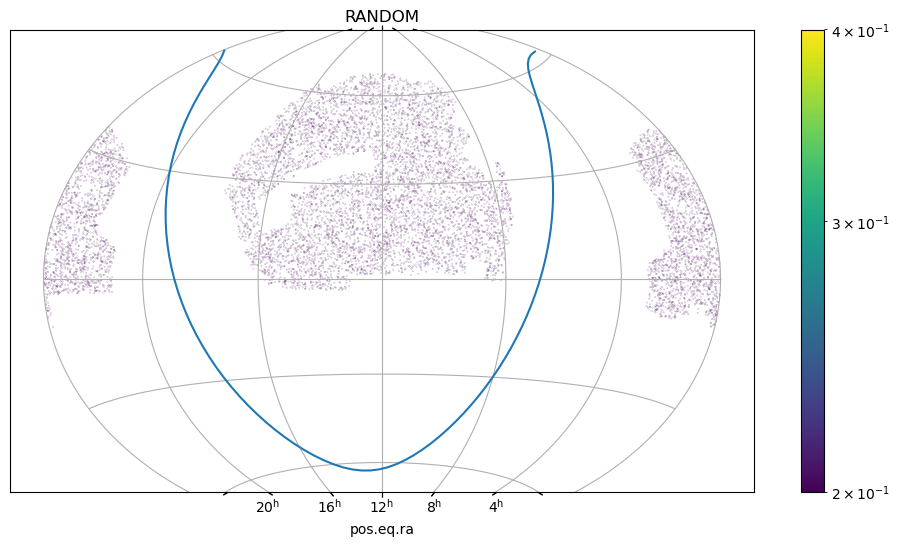

In [143]:
plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=w)
ax.set_title("RANDOM")
sc = ax.scatter(randoms_cut["ra"][::10], randoms_cut["dec"][::10], s=0.01, c=randoms_cut["z"][::10], norm='log', vmin=0.2, vmax=0.4, transform=ax.get_transform('world'))
ax.plot(gal_plane.ra.deg[sorted], gal_plane.dec.deg[sorted], transform=ax.get_transform('world'))
plt.colorbar(sc)
ax.grid()

In [144]:
# OVERDENSITY VALUE

import healpy as hp

nside = 128
npix = hp.nside2npix(nside)

# data
theta_data = np.pi/2 - np.deg2rad(galaxies_cut.dec)  # in radians
phi_data = np.deg2rad(galaxies_cut.ra)  # in radians
pix_d = hp.ang2pix(nside, theta_data, phi_data)
counts_d = np.bincount(pix_d, minlength=npix)

# randoms
theta_rand = np.pi/2 - np.deg2rad(randoms_cut.dec)
phi_rand = np.deg2rad(randoms_cut.ra)
pix_r = hp.ang2pix(nside, theta_rand, phi_rand)
counts_r = np.bincount(pix_r, minlength=npix)

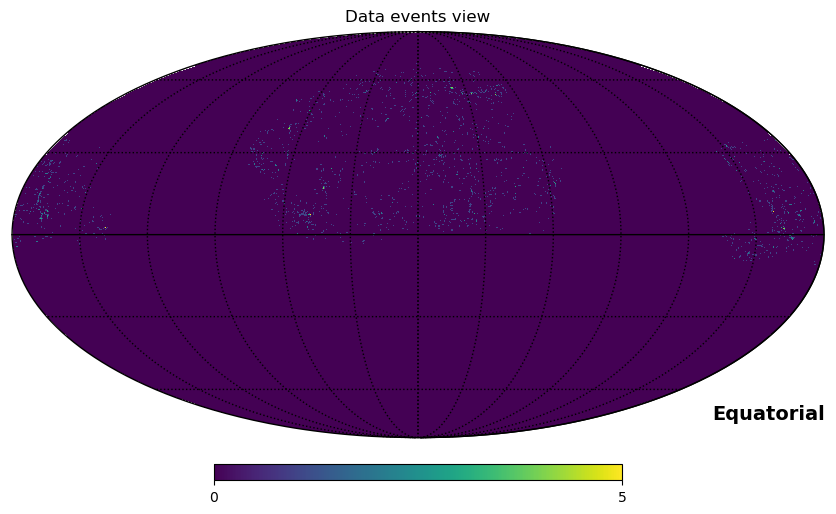

In [145]:
hp.mollview(counts_d, title="Data events view", rot=(180, 0, 0), coord='C', min=0, max=5)
hp.graticule()

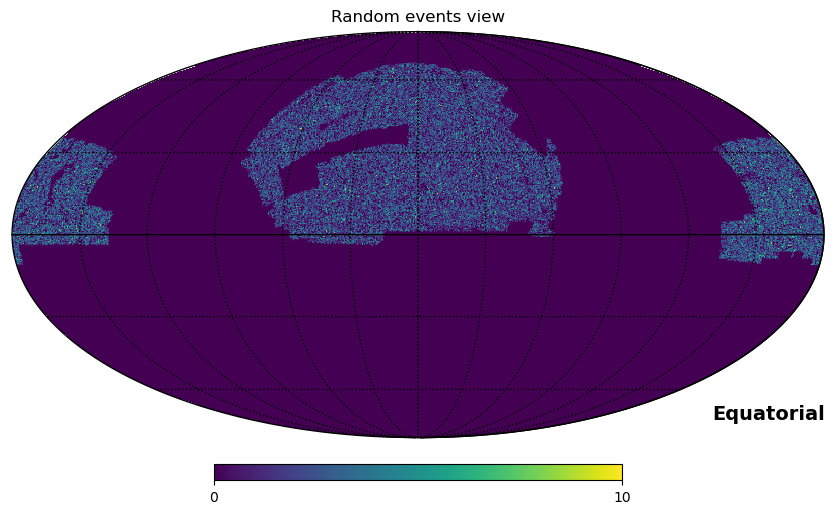

In [146]:
hp.mollview(counts_r, title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

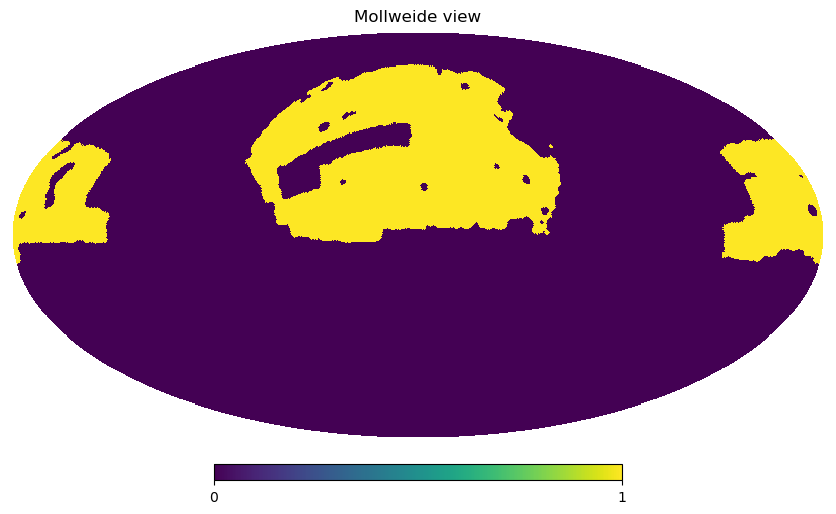

In [147]:
mask = np.zeros(npix)
pix = hp.ang2pix(nside, theta_rand, phi_rand)
mask[pix] = 1

# 2. smooth / fill
mask = hp.smoothing(mask, sigma=np.radians(1.0))
mask = (mask > 0.7).astype(float)

hp.mollview(mask, rot=(180, 0, 0))

In [148]:
print(f"SAMPLE DENSITY: {galaxies_cut.z.size / sum(mask)}")
print(f"RANDOM DENSITY: {randoms_cut.z.size / sum(mask)}")

SAMPLE DENSITY: 0.04687577547272818
RANDOM DENSITY: 2.2737108541366817


In [149]:
# normalization coefficient (data / sampling)
alpha = len(theta_data) / len(theta_rand)

# OVERDENSITY FUNCTION
delta = np.zeros(npix, dtype=float)

valid = counts_r > 0
delta[valid] = counts_d[valid] / (alpha * counts_r[valid]) - 1

delta_s = hp.smoothing(delta, sigma=np.radians(1.0))

In [150]:
print(np.nanmean(delta[valid]))   # should be ~0
print(np.nanstd(delta[valid]))    # reasonable scatter

print(np.nanmean(delta_s[valid]))   # should be ~0
print(np.nanstd(delta_s[valid]))    # reasonable scatter

0.14766551414186185
6.860198612614979
0.13377370866127336
1.1661429327019819


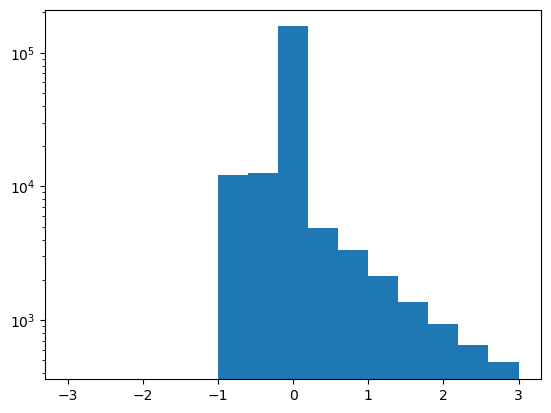

In [151]:
plt.hist(delta_s.ravel(), bins = [-3.0, -2.6, -2.2, -1.8, -1.4, -1, -0.6, -0.2, 0.2, 0.6, 1., 1.4, 1.8, 2.2, 2.6, 3.0])
plt.yscale('log')

In [134]:
np.save("sdss-overdensity-z-l005", delta)

In [98]:
MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg')
theta_MW, phi_MW = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

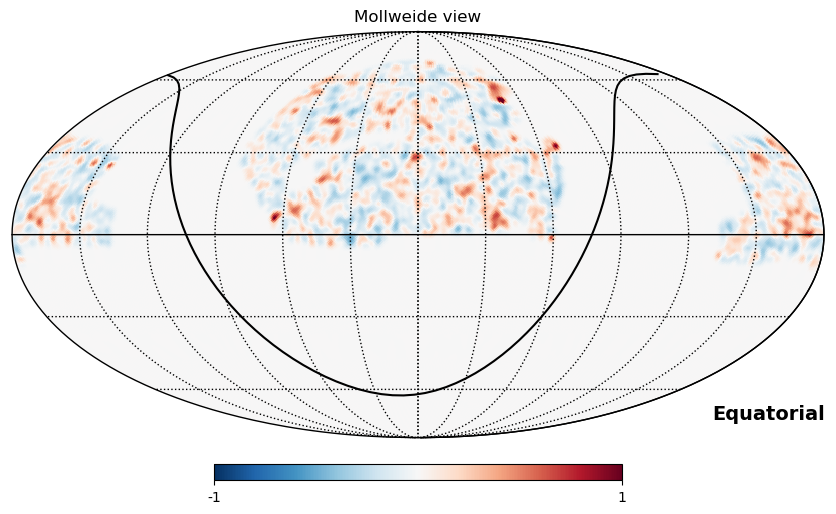

In [99]:
hp.mollview(delta_s, cmap='RdBu_r', min=-1.0, max=1.0, rot=(180, 0, 0), coord='C')
hp.projplot(theta_MW, phi_MW, coord=['G', 'C'], color='black')
hp.graticule()

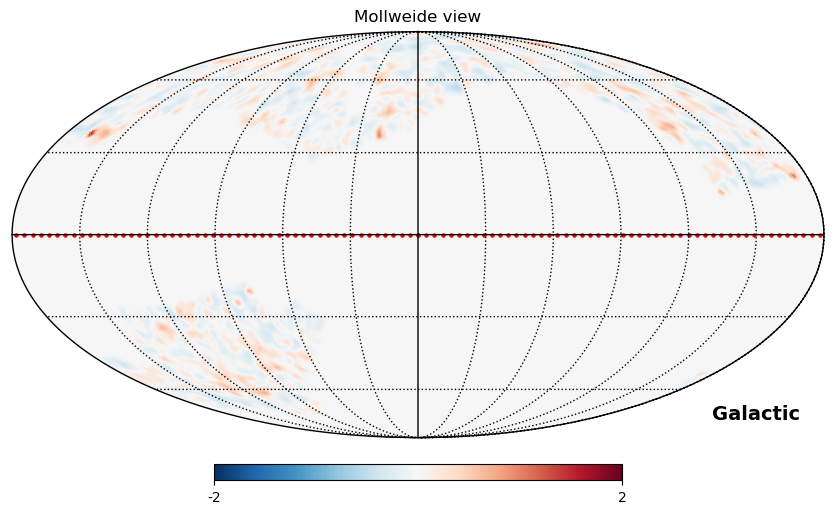

In [100]:
hp.mollview(delta_s, coord=['C', 'G'], cmap='RdBu_r', min=-2, max=2)
hp.projscatter(theta_MW, phi_MW, coord='G', marker='o', color='red', s=5)
hp.graticule()